# Colab D — PyTorch Lightning: 3-Layer Deep NN for Non-Linear Regression

**CMPE 258 — Deep Learning | Spring 2026 | San José State University**

**Author:** Parth  
**Instructor:** Vijay Eranti

---

## Overview

This notebook refactors the Colab C model into **PyTorch Lightning**, which provides:
- `LightningModule` — encapsulates model + training/validation logic
- `LightningDataModule` — encapsulates data loading
- `Trainer` — handles epochs, logging, GPU, callbacks
- Built-in logging, progress bars, and checkpointing

### Architecture (same as all colabs)
```
Input(3) → Linear(64)+ReLU → Linear(32)+Tanh → Linear(16)+ReLU → Linear(1)
```

## 1. Environment Setup

In [1]:
!pip install -q pytorch-lightning

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)
pl.seed_everything(42)

print(f'PyTorch: {torch.__version__}')
print(f'Lightning: {pl.__version__}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 43.0 MB/s eta 0:00:00


INFO:lightning_fabric.utilities.seed:Seed set to 42


PyTorch: 2.10.0+cu128
Lightning: 2.6.1


## 2. Data Generation

In [2]:
n_samples = 500
X_np = np.random.uniform(-1, 1, (n_samples, 3)).astype(np.float32)
x1, x2, x3 = X_np[:, 0:1], X_np[:, 1:2], X_np[:, 2:3]

y_np = (3.0 * x1**2
        + 2.0 * np.sin(np.pi * x2) * x3
        - x3**3
        + 0.5 * x1 * x2
        + 1.0).astype(np.float32)

print(f'X: {X_np.shape}  |  y: {y_np.shape}')

X: (500, 3)  |  y: (500, 1)


## 3. LightningDataModule

Encapsulates data preparation, train/val split, and DataLoader creation.

In [3]:
class RegressionDataModule(pl.LightningDataModule):
    """Lightning DataModule for our non-linear regression data."""

    def __init__(self, X, y, batch_size=64, val_split=0.2):
        super().__init__()
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        self.batch_size = batch_size
        self.val_split = val_split

    def setup(self, stage=None):
        dataset = TensorDataset(self.X, self.y)
        n_val = int(len(dataset) * self.val_split)
        n_train = len(dataset) - n_val
        self.train_ds, self.val_ds = torch.utils.data.random_split(
            dataset, [n_train, n_val]
        )

    def train_dataloader(self):
        return DataLoader(self.train_ds, batch_size=self.batch_size, shuffle=True)

    def val_dataloader(self):
        return DataLoader(self.val_ds, batch_size=self.batch_size)

    def predict_dataloader(self):
        return DataLoader(TensorDataset(self.X, self.y), batch_size=self.batch_size)


dm = RegressionDataModule(X_np, y_np, batch_size=64)
print('DataModule created ✓')

DataModule created ✓


## 4. LightningModule

Encapsulates model architecture, loss, optimizer, and training/validation step logic.

In [4]:
class DeepNet3LayerLit(pl.LightningModule):
    """
    Lightning version of 3-Hidden-Layer Deep NN for non-linear regression.

    Architecture:
      Input(3) → Linear(64)+ReLU → Linear(32)+Tanh → Linear(16)+ReLU → Linear(1)
    """

    def __init__(self, input_dim=3, h1=64, h2=32, h3=16, lr=0.005):
        super().__init__()
        self.save_hyperparameters()
        self.lr = lr

        self.network = nn.Sequential(
            nn.Linear(input_dim, h1),
            nn.ReLU(),
            nn.Linear(h1, h2),
            nn.Tanh(),
            nn.Linear(h2, h3),
            nn.ReLU(),
            nn.Linear(h3, 1)
        )
        self.criterion = nn.MSELoss()

        # Store losses for plotting
        self.train_losses = []
        self.val_losses = []

        # He initialization
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.network(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = self.criterion(y_pred, y)
        self.log('train_loss', loss, prog_bar=True)
        return loss

    def on_train_epoch_end(self):
        avg_loss = self.trainer.callback_metrics.get('train_loss')
        if avg_loss is not None:
            self.train_losses.append(avg_loss.item())

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = self.criterion(y_pred, y)
        self.log('val_loss', loss, prog_bar=True)
        return loss

    def on_validation_epoch_end(self):
        avg_loss = self.trainer.callback_metrics.get('val_loss')
        if avg_loss is not None:
            self.val_losses.append(avg_loss.item())

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)


model = DeepNet3LayerLit()
print(model)
print(f'\nHyperparameters: {model.hparams}')

DeepNet3LayerLit(
  (network): Sequential(
    (0): Linear(in_features=3, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): Tanh()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=1, bias=True)
  )
  (criterion): MSELoss()
)

Hyperparameters: "h1":        64
"h2":        32
"h3":        16
"input_dim": 3
"lr":        0.005


## 5. Training with Lightning Trainer

The `Trainer` handles epoch loops, GPU management, logging, and callbacks automatically.

In [5]:
# --- Train with Lightning Trainer ---
trainer = pl.Trainer(
    max_epochs=500,
    accelerator='auto',
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=30, mode='min'),
    ],
    enable_progress_bar=True,
    log_every_n_steps=5,
)

trainer.fit(model, dm)
print(f'\nTraining complete. Best val_loss: {trainer.callback_metrics.get("val_loss", "N/A")}')

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ network   │ Sequential │  2.9 K │ train │     0 │
│ 1 │ criterion │ MSELoss    │      0 │ train │     0 │
└───┴───────────┴────────────┴────────┴───────┴───────┘

Trainable params: 2.9 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.9 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 9                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()


Training complete. Best val_loss: 0.01923619583249092


## 6. Results

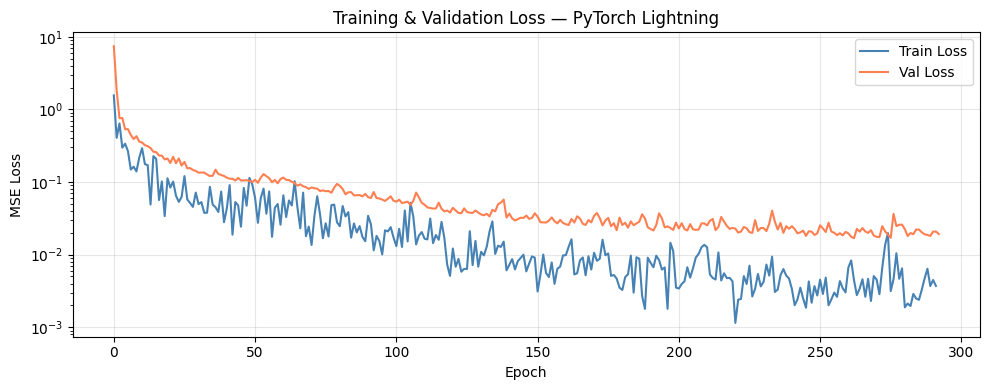

In [6]:
# --- Loss Curves ---
fig, ax = plt.subplots(figsize=(10, 4))
if model.train_losses:
    ax.plot(model.train_losses, label='Train Loss', color='steelblue')
if model.val_losses:
    ax.plot(model.val_losses, label='Val Loss', color='coral')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
ax.set_title('Training & Validation Loss — PyTorch Lightning')
ax.legend(); ax.grid(True, alpha=0.3)
ax.set_yscale('log')
plt.tight_layout()
plt.show()

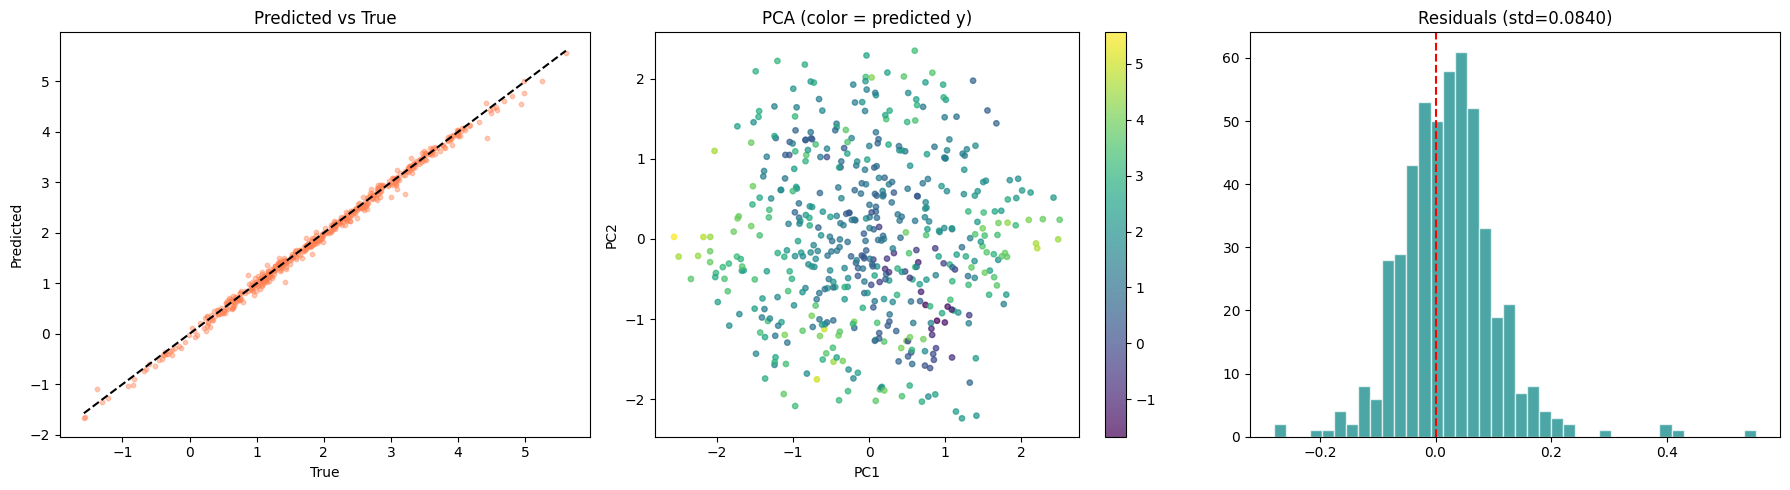

R² score: 0.9953


In [7]:
# --- Evaluation ---
model.eval()
X_t = torch.tensor(X_np, dtype=torch.float32)
with torch.no_grad():
    y_final = model(X_t).numpy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Predicted vs True
axes[0].scatter(y_np, y_final, alpha=0.4, s=10, color='coral')
lims = [y_np.min(), y_np.max()]
axes[0].plot(lims, lims, 'k--', lw=1.5)
axes[0].set_xlabel('True'); axes[0].set_ylabel('Predicted')
axes[0].set_title('Predicted vs True')

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(StandardScaler().fit_transform(X_np))
sc = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=y_final.flatten(),
                     cmap='viridis', alpha=0.7, s=15)
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].set_title('PCA (color = predicted y)')
plt.colorbar(sc, ax=axes[1])

# Residuals
residuals = (y_np - y_final).flatten()
axes[2].hist(residuals, bins=40, color='teal', alpha=0.7, edgecolor='white')
axes[2].axvline(0, color='red', linestyle='--')
axes[2].set_title(f'Residuals (std={residuals.std():.4f})')

plt.tight_layout()
plt.show()

# R²
ss_res = np.sum((y_np - y_final)**2)
ss_tot = np.sum((y_np - y_np.mean())**2)
print(f'R² score: {1 - ss_res/ss_tot:.4f}')

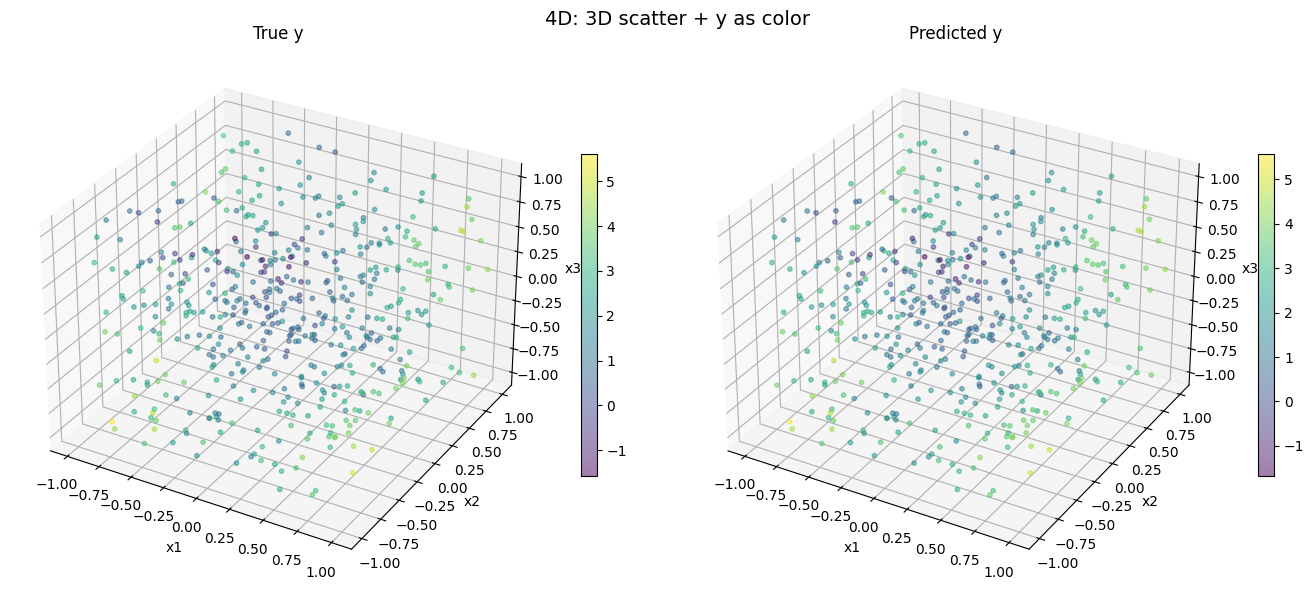

In [8]:
# --- 4D Plot ---
fig = plt.figure(figsize=(14, 6))
for i, (data, title) in enumerate([(y_np, 'True y'), (y_final, 'Predicted y')]):
    ax = fig.add_subplot(1, 2, i+1, projection='3d')
    sc = ax.scatter(X_np[:, 0], X_np[:, 1], X_np[:, 2],
                    c=data.flatten(), cmap='viridis', alpha=0.5, s=10)
    ax.set_xlabel('x1'); ax.set_ylabel('x2'); ax.set_zlabel('x3')
    ax.set_title(title)
    plt.colorbar(sc, ax=ax, shrink=0.6)
plt.suptitle('4D: 3D scatter + y as color', fontsize=14)
plt.tight_layout()
plt.show()

## 7. Summary

| Lightning Feature | What it replaces |
|-------------------|------------------|
| `LightningModule` | Manual training loop |
| `LightningDataModule` | Manual DataLoader setup |
| `Trainer` | Epoch loop, GPU handling, logging |
| `EarlyStopping` | Manual patience tracking |
| `self.log()` | Manual loss recording |
| `save_hyperparameters()` | Manual config tracking |

Same architecture and results as Colab C, but with much cleaner separation of concerns.